# Solving the TOV equations

Example code for solving the TOV equations with a polytropic equation of state.

Load parameters

In [1]:
include("params.jl");

In [2]:
h = 4e-4; # radial step size in TOV solution [km]

Solve TOV equations using two different methods: an explicit RK4 integration and a second-order accurate implicit Crank-Nicholson scheme.

In [3]:
using NeutronStarOscillations

In [4]:
@time solve_TOV(BDNK_star, h); # explicit RK4 solver

  0.817078 seconds (1.30 M allocations: 30.394 MiB, 29.30% gc time, 63.87% compilation time: 84% of which was recompilation)


Load solution

In [5]:
r, m, p, ε, ν = load_TOV(BDNK_star, h);

In [6]:
println("Stellar mass = $(m[end] / NeutronStarOscillations.Msun_to_km) solar masses, stellar radius = $(r[end]) km")

Stellar mass = 1.5387775667009365 solar masses, stellar radius = 8.773200000000001 km


Plot TOV solutions. The gravitational mass is plotted in units of solar masses; the pressure and energy are normalized by their value at the center; the metric function $\nu$ is divided by its value at the surface.

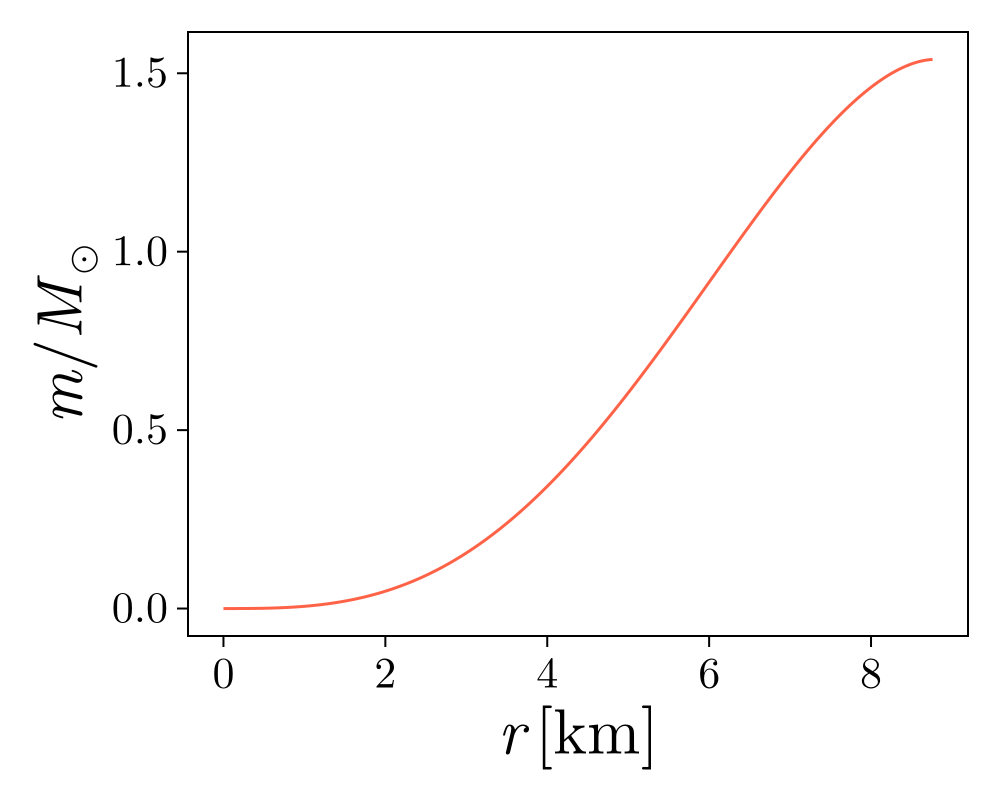

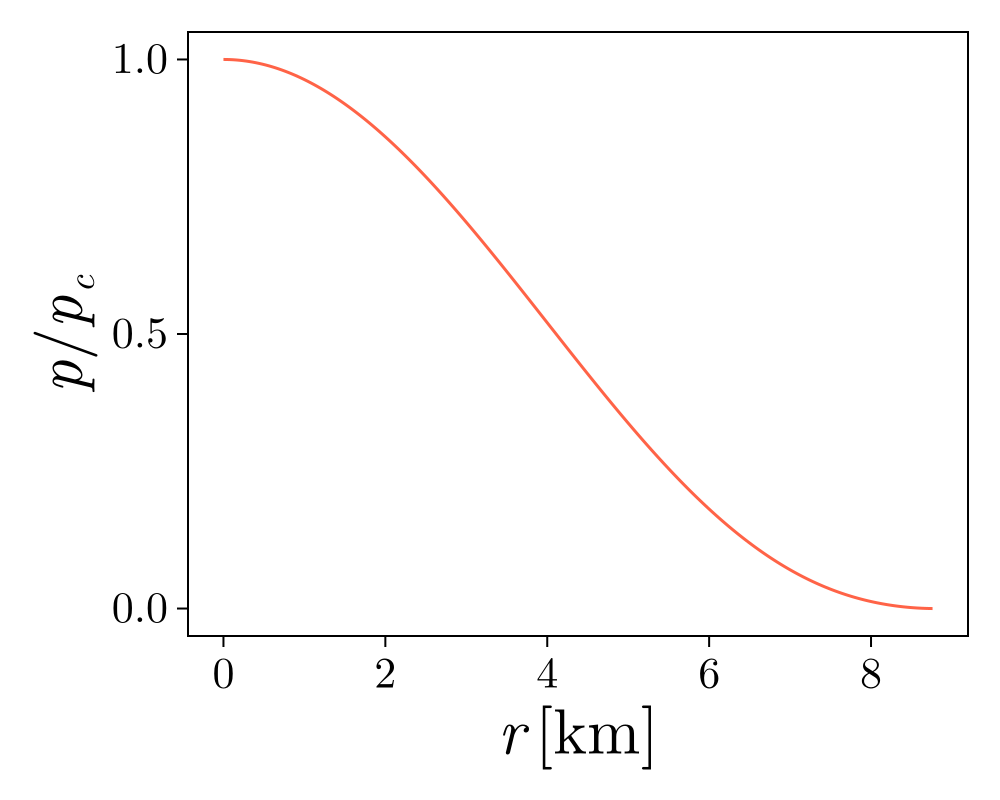

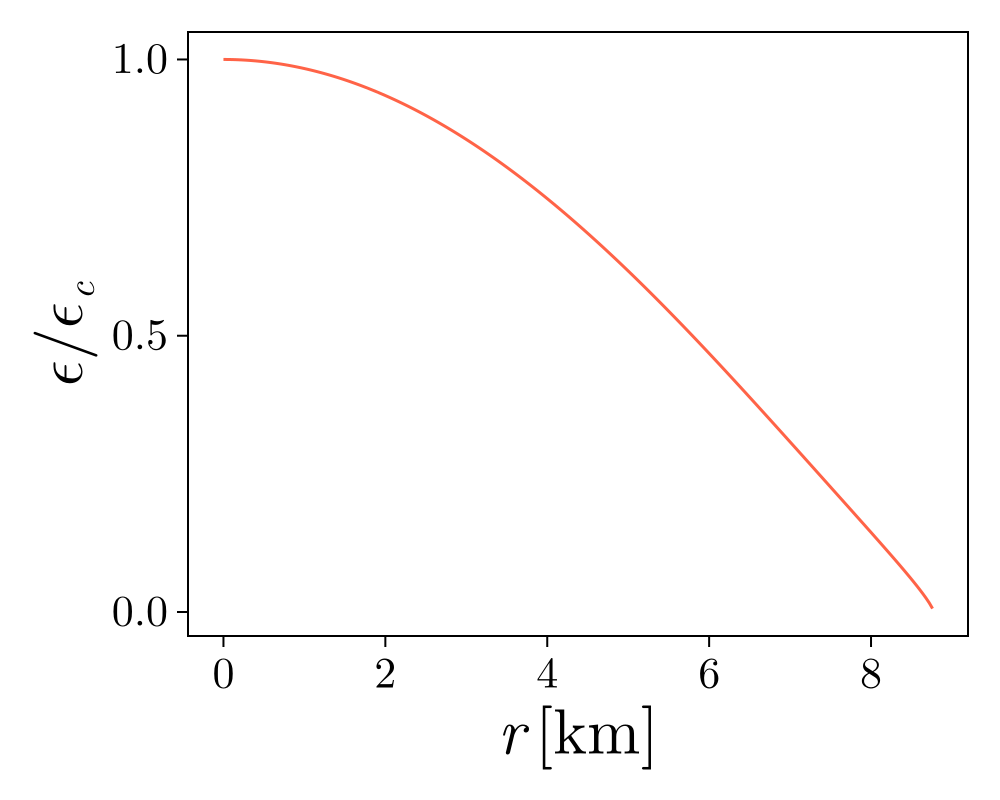

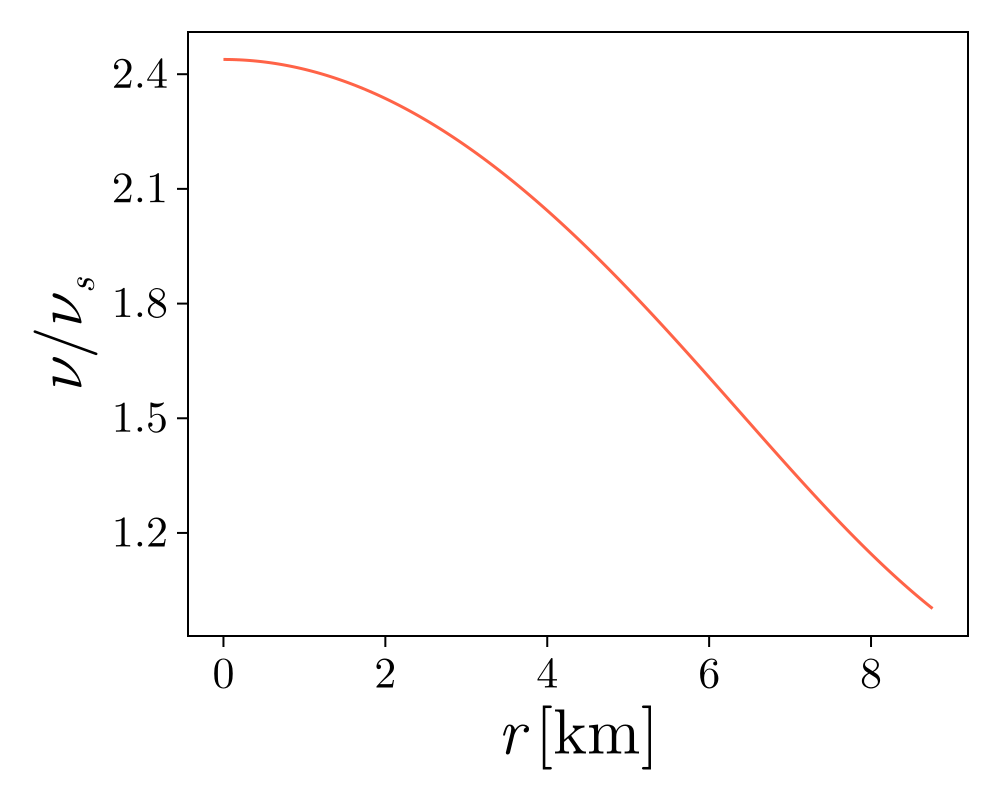

In [7]:
vars = ["mass", "pressure", "energy_density", "nu"]
xlabel = L"r\,[\mathrm{km}]";
ylabels = [L"m / M_{\odot}", L"p / p_{c}", L"\epsilon / \epsilon_{c}", L"\nu / \nu_{s}"];
legend = false;
plot_desample_factor = 100; # desampling factor for plots to reduce number of points plotted

for i in eachindex(vars)
    var = vars[i];
    ylabel = ylabels[i];
    plot_TOV_var(var, BDNK_star, h; 
        desample_factor = plot_desample_factor,
        xlabel = xlabel,
        ylabel = ylabel,
        legend = legend,
    );
end